In [20]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [21]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

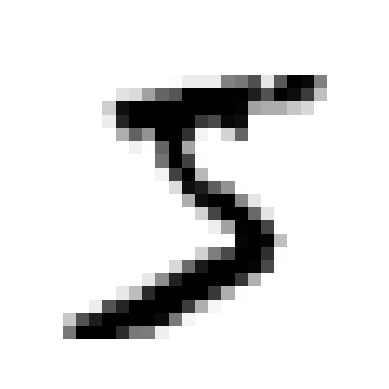

In [22]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)

plt.show()

In [23]:
y[0]

'5'

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

In [25]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

y_pred = lr_clf.predict(X_test)
y_pred

c:\Users\konta\anaconda3\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['1', '3', '9', ..., '6', '0', '7'], shape=(35000,), dtype=object)

In [26]:
y_test

array(['1', '3', '9', ..., '4', '0', '7'], shape=(35000,), dtype=object)

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[3363,    0,   10,   11,    8,   30,   27,   11,   27,    6],
       [   0, 3813,   17,   15,    5,   16,    3,   10,   41,   12],
       [  17,   33, 3039,   61,   49,   24,   51,   32,   78,   13],
       [  17,   13,   79, 3195,    8,  117,   10,   31,   81,   22],
       [  10,   11,   12,    8, 3171,    3,   32,   12,   31,  114],
       [  27,   14,   27,  123,   42, 2713,   79,   18,  134,   37],
       [  25,   11,   30,    1,   26,   37, 3256,    5,   14,    1],
       [  11,   19,   50,   14,   42,    4,    1, 3435,   15,  131],
       [  20,   54,   48,   76,   19,   86,   36,   15, 2964,   50],
       [  22,   12,    8,   51,  108,   20,    1,  122,   35, 3112]])

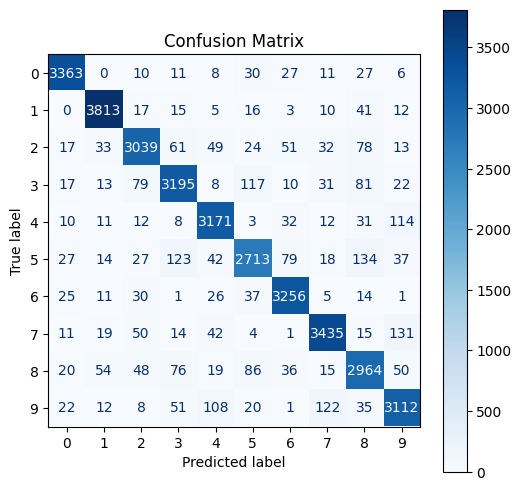

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [29]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=123)
sgd_clf.fit(X_train, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


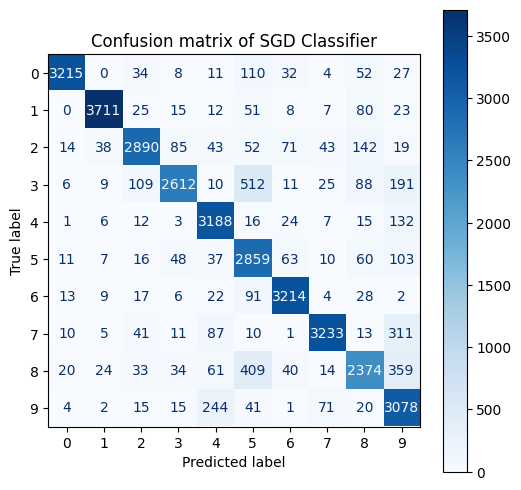

In [31]:
y_pred = sgd_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sgd_clf.classes_)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion matrix of SGD Classifier')
plt.show()

In [46]:
import numpy as np

Dio_Sum = 0

for i in range(10):
    Dio_Sum += cm[i, i]

accuracy = Dio_Sum / np.sum(cm)

accuracy

np.float64(0.8678285714285714)

In [49]:
from sklearn.metrics import accuracy_score

print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Manually: ', np.trace(cm) / np.sum(cm))

Accuracy:  0.8678285714285714
Manually:  0.8678285714285714


In [50]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

Balanced Accuracy: 0.8671
